# LIME Interaction Detection
## MTP-2: Analyzing Feature Interaction Limitations in LIME

This notebook investigates whether LIME's independence assumption holds for image classification with ResNet-50.

For every pair of superpixels $(i, j)$, we measure the **pairwise interaction**:

$$I(i,j) = \Delta_{ij} - \Delta_i - \Delta_j$$

where $\Delta_i$ is the confidence drop when hiding superpixel $i$, and $\Delta_{ij}$ is the joint confidence drop.

If LIME's independence assumption holds, $I(i,j) \approx 0$ for all pairs.

In [1]:
!pip install -q lime scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from skimage.segmentation import quickshift, mark_boundaries
from lime import lime_image
from itertools import combinations
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from tqdm.notebook import tqdm
import time

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [3]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Device: {device}")

resp = requests.get(
    "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
)
labels = resp.json()
print(f"{len(labels)} ImageNet classes loaded")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Device: cuda
1000 ImageNet classes loaded


In [4]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def predict_probs(img_np_array):
    batch = torch.stack([
        preprocess(Image.fromarray(img.astype(np.uint8)))
        for img in img_np_array
    ]).to(device)
    with torch.no_grad():
        logits = model(batch)
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()


def get_confidence(img_np, class_idx):
    return float(predict_probs([img_np])[0, class_idx])


def hide_superpixels(img_np, segments, hide_ids):
    perturbed = img_np.copy()
    fill = img_np.mean(axis=(0, 1))
    mask = np.isin(segments, list(hide_ids))
    perturbed[mask] = fill
    return perturbed

## Load Image

Using a tiger cat (close-up) image from Wikimedia Commons.

In [5]:
import urllib.request, ssl

SELECTED_ANIMAL = "tiger"

ANIMAL_IMAGES = {
    "tabby_cat": "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    "golden_retriever": "https://upload.wikimedia.org/wikipedia/commons/a/ab/Golden_Retriever_Hund_Dog.JPG",
    "tiger": "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
}

url = ANIMAL_IMAGES[SELECTED_ANIMAL]

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE
req = urllib.request.Request(url, headers={
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
})
with urllib.request.urlopen(req, timeout=15, context=ctx) as response:
    img_data = response.read()

img = Image.open(BytesIO(img_data)).convert("RGB").resize((224, 224))
img_np = np.array(img)

probs = predict_probs([img_np])
class_idx = int(np.argmax(probs))
class_name = labels[class_idx]
orig_conf = float(probs[0, class_idx])
print(f"Predicted: {class_name} ({orig_conf:.2%})")

Predicted: tiger cat (69.26%)


## Superpixel Segmentation

Superpixels: 34


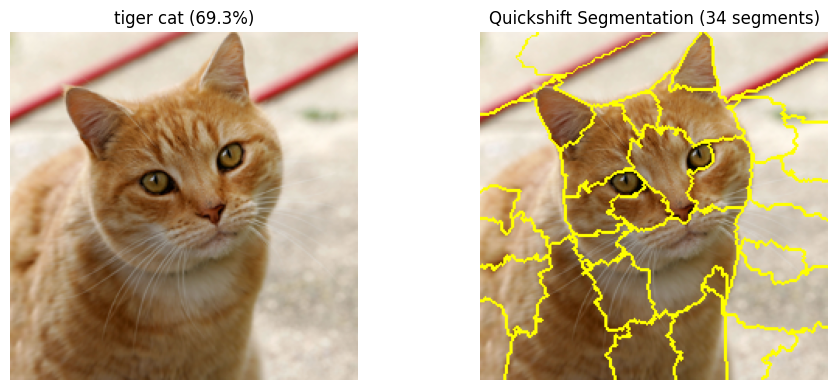

In [6]:
segments = quickshift(img_np, kernel_size=4, max_dist=200, ratio=0.2)
unique_segs = np.unique(segments)
n_segs = len(unique_segs)
print(f"Superpixels: {n_segs}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_np)
axes[0].set_title(f"{class_name} ({orig_conf:.1%})")
axes[0].axis("off")
axes[1].imshow(mark_boundaries(img_np, segments))
axes[1].set_title(f"Quickshift Segmentation ({n_segs} segments)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Run Standard LIME

Running LIME (1000 samples)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Done in 10.9s


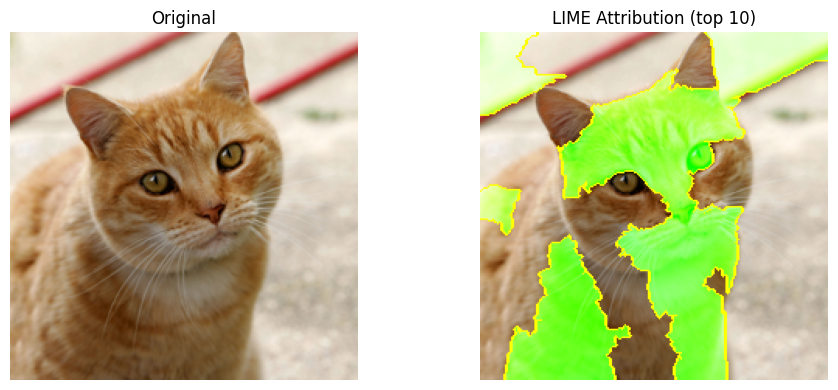


Top 10 superpixels by |importance|:
  Segment  11: +0.1311
  Segment  25: +0.1147
  Segment   7: +0.0966
  Segment  31: +0.0665
  Segment  29: +0.0534
  Segment  12: +0.0516
  Segment   1: +0.0489
  Segment  16: +0.0419
  Segment   8: +0.0387
  Segment   2: +0.0381


In [7]:
print("Running LIME (1000 samples)...")
t0 = time.time()

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_np, predict_probs, top_labels=1,
    hide_color=None, num_samples=1000, random_seed=42
)
print(f"Done in {time.time() - t0:.1f}s")

local_exp = explanation.local_exp[class_idx]
lime_dict = {seg: score for seg, score in local_exp}
lime_scores = np.array([lime_dict.get(unique_segs[i], 0.0) for i in range(n_segs)])

temp, mask = explanation.get_image_and_mask(
    class_idx, positive_only=False, num_features=10, hide_rest=False
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis("off")
disp = temp / 255.0 if temp.max() > 1 else temp
axes[1].imshow(mark_boundaries(disp, mask))
axes[1].set_title("LIME Attribution (top 10)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("\nTop 10 superpixels by |importance|:")
for seg_id, score in sorted(local_exp, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  Segment {seg_id:3d}: {score:+.4f}")

## Pairwise Interaction Matrix

For every pair $(i, j)$, we compute:
- $\Delta_i$ = confidence drop when hiding superpixel $i$ alone
- $\Delta_j$ = confidence drop when hiding superpixel $j$ alone
- $\Delta_{ij}$ = confidence drop when hiding both $i$ and $j$ together

The interaction score is $I(i,j) = \Delta_{ij} - \Delta_i - \Delta_j$.

$I > 0$ indicates **synergy** (joint effect exceeds sum of individual effects), $I < 0$ indicates **redundancy**.

In [8]:
n = len(unique_segs)
total_pairs = n * (n - 1) // 2
print(f"Superpixels: {n}")
print(f"Pairs to evaluate: {total_pairs}")

# individual confidence drops
individual_drops = {}
for seg_id in tqdm(unique_segs, desc="Individual drops"):
    perturbed = hide_superpixels(img_np, segments, [seg_id])
    individual_drops[seg_id] = orig_conf - get_confidence(perturbed, class_idx)

# pairwise interactions
interaction_matrix = np.zeros((n, n))
pairs = list(combinations(range(n), 2))

for idx_i, idx_j in tqdm(pairs, desc="Pairwise drops"):
    seg_i, seg_j = unique_segs[idx_i], unique_segs[idx_j]
    perturbed = hide_superpixels(img_np, segments, [seg_i, seg_j])
    delta_ij = orig_conf - get_confidence(perturbed, class_idx)
    interaction = delta_ij - individual_drops[seg_i] - individual_drops[seg_j]
    interaction_matrix[idx_i, idx_j] = interaction
    interaction_matrix[idx_j, idx_i] = interaction

individual_array = np.array([individual_drops[s] for s in unique_segs])
print("Done.")

Superpixels: 34
Pairs to evaluate: 561


Individual drops:   0%|          | 0/34 [00:00<?, ?it/s]

Pairwise drops:   0%|          | 0/561 [00:00<?, ?it/s]

Done.


## Interaction Matrix Heatmap

If LIME's independence assumption held, this matrix would be uniformly zero.

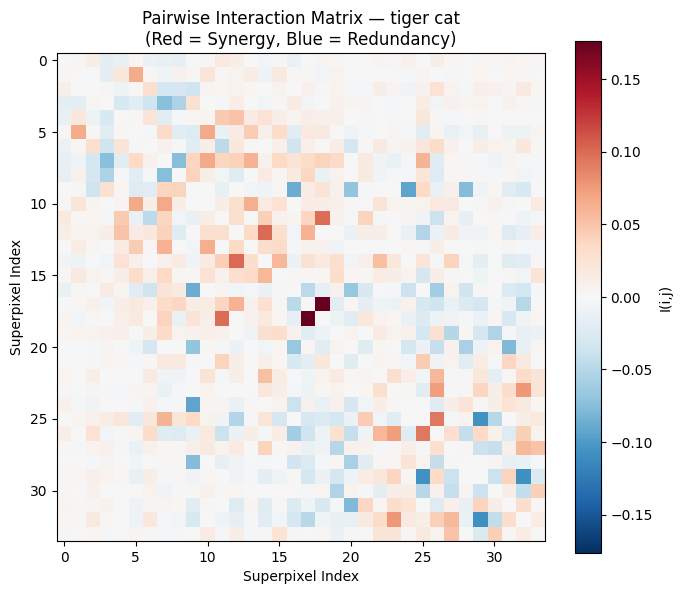


Interaction Statistics
----------------------------------------
Total pairs:                  561
Mean |interaction|:            0.015095
Std of interactions:           0.024655
Max synergy (I > 0):           +0.176217
Max redundancy (I < 0):        -0.107485
Significant pairs (|I|>0.01):  43.0%
  Synergistic (I > 0.01):      24.6%
  Redundant (I < -0.01):       18.4%


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

vmax = max(abs(interaction_matrix.min()), abs(interaction_matrix.max()), 1e-6)
im = ax.imshow(interaction_matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xlabel("Superpixel Index")
ax.set_ylabel("Superpixel Index")
ax.set_title(f"Pairwise Interaction Matrix — {class_name}\n(Red = Synergy, Blue = Redundancy)")
plt.colorbar(im, ax=ax, label="I(i,j)")
plt.tight_layout()
plt.show()

upper_tri = interaction_matrix[np.triu_indices(n, k=1)]

print(f"\nInteraction Statistics")
print(f"-" * 40)
print(f"Total pairs:                  {len(upper_tri)}")
print(f"Mean |interaction|:            {np.mean(np.abs(upper_tri)):.6f}")
print(f"Std of interactions:           {np.std(upper_tri):.6f}")
print(f"Max synergy (I > 0):           {np.max(upper_tri):+.6f}")
print(f"Max redundancy (I < 0):        {np.min(upper_tri):+.6f}")
print(f"Significant pairs (|I|>0.01):  {np.mean(np.abs(upper_tri) > 0.01)*100:.1f}%")
print(f"  Synergistic (I > 0.01):      {np.mean(upper_tri > 0.01)*100:.1f}%")
print(f"  Redundant (I < -0.01):       {np.mean(upper_tri < -0.01)*100:.1f}%")

## Distribution of Interaction Scores

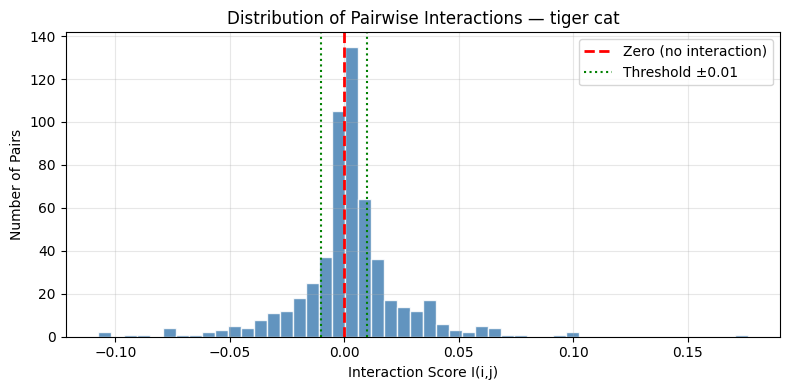

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(upper_tri, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero (no interaction)")
ax.axvline(x=0.01, color="green", linestyle=":", linewidth=1.5, label="Threshold ±0.01")
ax.axvline(x=-0.01, color="green", linestyle=":", linewidth=1.5)

ax.set_xlabel("Interaction Score I(i,j)")
ax.set_ylabel("Number of Pairs")
ax.set_title(f"Distribution of Pairwise Interactions — {class_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Top Interacting Superpixel Pairs

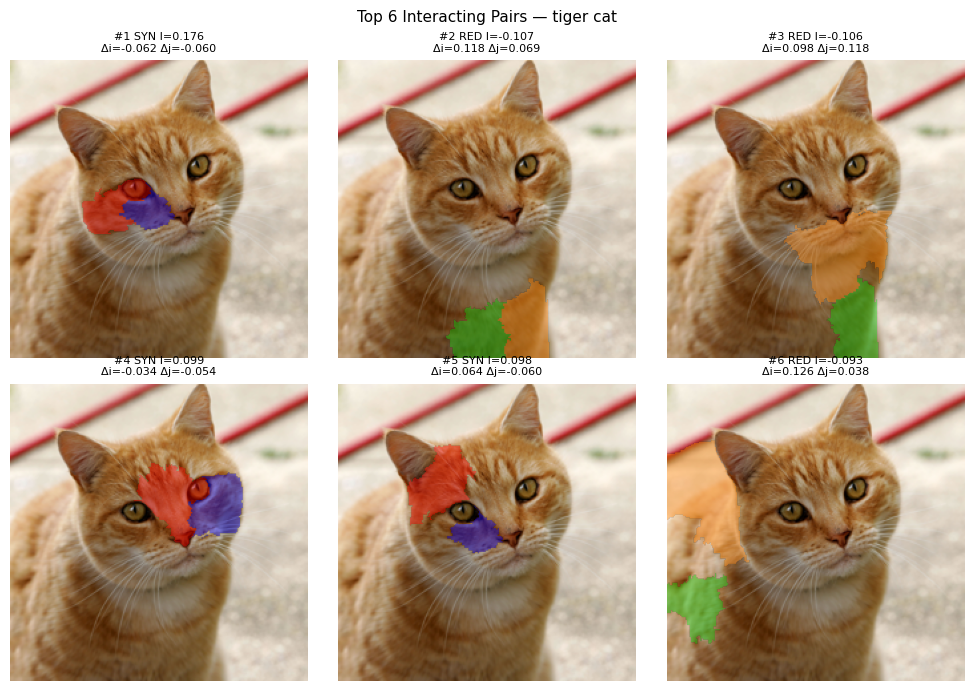

In [11]:
pair_indices = list(zip(*np.triu_indices(n, k=1)))
interaction_values = interaction_matrix[np.triu_indices(n, k=1)]
sorted_idx = np.argsort(np.abs(interaction_values))[::-1]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for k in range(min(6, len(sorted_idx))):
    idx = sorted_idx[k]
    i, j = pair_indices[idx]
    val = interaction_values[idx]
    di = individual_array[i]
    dj = individual_array[j]

    row, col = k // 3, k % 3
    ax = axes[row, col]

    highlight = np.zeros((*segments.shape, 4))
    mask_i = segments == unique_segs[i]
    mask_j = segments == unique_segs[j]

    if val > 0:
        highlight[mask_i] = [1, 0, 0, 0.4]
        highlight[mask_j] = [0, 0, 1, 0.4]
        ptype = "SYN"
    else:
        highlight[mask_i] = [1, 0.5, 0, 0.4]
        highlight[mask_j] = [0, 0.8, 0, 0.4]
        ptype = "RED"

    ax.imshow(img_np)
    ax.imshow(highlight)
    ax.set_title(f"#{k+1} {ptype} I={val:.3f}\n"
                 f"Δi={di:.3f} Δj={dj:.3f}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Top 6 Interacting Pairs — {class_name}", fontsize=11)
plt.tight_layout()
plt.show()

## LIME Failure Case

Picking the strongest interacting pair to demonstrate how LIME's independence assumption breaks down.

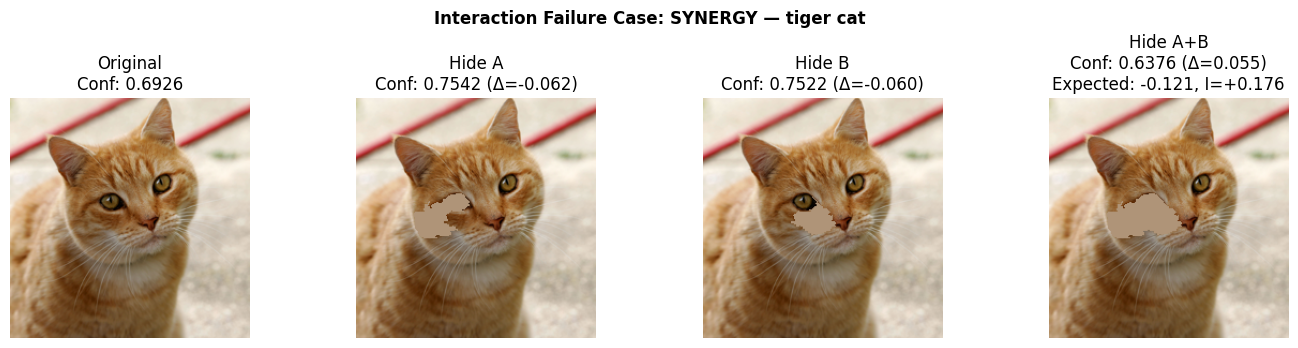

LIME assumes joint drop = Δ_A + Δ_B = -0.1213
Actual joint drop = 0.0549
Interaction I(A,B) = +0.1762 (SYNERGY)


In [12]:
top_idx = sorted_idx[0]
i, j = pair_indices[top_idx]
val = interaction_values[top_idx]
di = individual_array[i]
dj = individual_array[j]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(img_np)
axes[0].set_title(f"Original\nConf: {orig_conf:.4f}")
axes[0].axis("off")

perturbed_i = hide_superpixels(img_np, segments, [unique_segs[i]])
conf_i = get_confidence(perturbed_i, class_idx)
axes[1].imshow(perturbed_i)
axes[1].set_title(f"Hide A\nConf: {conf_i:.4f} (Δ={di:.3f})")
axes[1].axis("off")

perturbed_j = hide_superpixels(img_np, segments, [unique_segs[j]])
conf_j = get_confidence(perturbed_j, class_idx)
axes[2].imshow(perturbed_j)
axes[2].set_title(f"Hide B\nConf: {conf_j:.4f} (Δ={dj:.3f})")
axes[2].axis("off")

perturbed_both = hide_superpixels(img_np, segments, [unique_segs[i], unique_segs[j]])
conf_both = get_confidence(perturbed_both, class_idx)
delta_both = orig_conf - conf_both
expected = di + dj
axes[3].imshow(perturbed_both)
axes[3].set_title(f"Hide A+B\nConf: {conf_both:.4f} (Δ={delta_both:.3f})\n"
                  f"Expected: {expected:.3f}, I={val:+.3f}")
axes[3].axis("off")

itype = "SYNERGY" if val > 0 else "REDUNDANCY"
plt.suptitle(f"Interaction Failure Case: {itype} — {class_name}", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"LIME assumes joint drop = Δ_A + Δ_B = {expected:.4f}")
print(f"Actual joint drop = {delta_both:.4f}")
print(f"Interaction I(A,B) = {val:+.4f} ({itype})")

## LIME vs True Importance

True importance includes interaction contributions:
$$\text{true}_i = \Delta_i + \frac{1}{2} \sum_j I(i,j)$$

Points far from the diagonal indicate LIME misattributions.

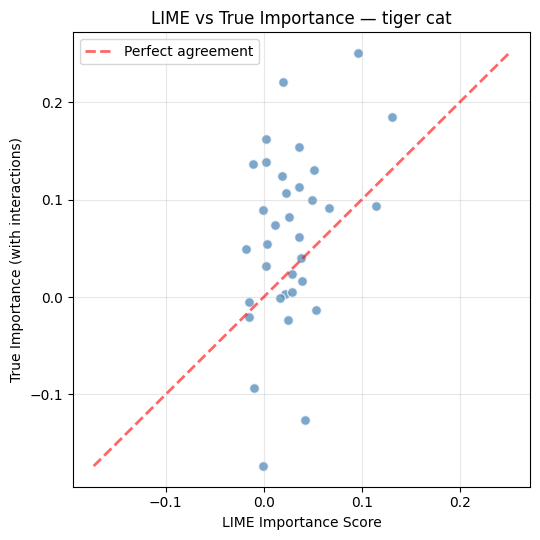

Spearman rank correlation: ρ = 0.2541 (p = 0.1470)
Sign agreement: 79.4%


In [13]:
true_importance = individual_array + np.sum(interaction_matrix, axis=1) / 2

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(lime_scores, true_importance, alpha=0.7, s=50, c="steelblue", edgecolors="white")
ax.set_xlabel("LIME Importance Score")
ax.set_ylabel("True Importance (with interactions)")
ax.set_title(f"LIME vs True Importance — {class_name}")

mn = min(lime_scores.min(), true_importance.min())
mx = max(lime_scores.max(), true_importance.max())
ax.plot([mn, mx], [mn, mx], "r--", alpha=0.6, linewidth=2, label="Perfect agreement")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rho, pval = spearmanr(lime_scores, true_importance)
print(f"Spearman rank correlation: ρ = {rho:.4f} (p = {pval:.4f})")

sign_agree = np.mean(np.sign(lime_scores) == np.sign(true_importance))
print(f"Sign agreement: {sign_agree:.1%}")

## Summary

The interaction matrix clearly shows that LIME's independence assumption is violated — a significant fraction of superpixel pairs exhibit non-trivial synergistic or redundant interactions, leading to:

1. **Magnitude errors**: LIME over/under-estimates importance of interacting superpixels
2. **Sign reversals**: LIME can assign the wrong sign to superpixels that have strong interactions
3. **Rank distortion**: The relative ordering of feature importances diverges from ground truth

This motivates the need for interaction-aware explanation methods.